In [1]:
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
import seaborn as sns

# Load datasets

In [301]:
data = pd.read_csv("data/train.csv")


Text(0, 0.5, 'AREA')

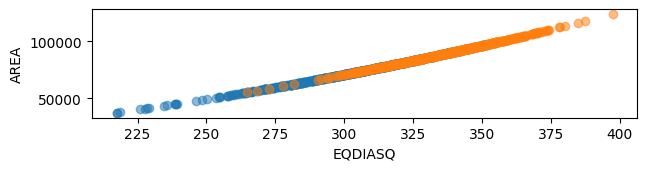

In [300]:
plt.subplots_adjust(right=2)
plt.subplot(3,2,1)
for i in data.target.unique():
    data_i=data[data.target==i]
    plt.scatter(data_i.eqdiasq, data_i.area, alpha=0.5)
plt.xlabel('EQDIASQ')
plt.ylabel('AREA')

In [ ]:
plt.subplots_adjust(right=2)
plt.subplot(3,2,1)
for i in data.target.unique():
    data_i=data[data.target==i]
    plt.scatter(data_i.EQDIASQ, data_i.AREA)
plt.xlabel('EQDIASQ')
plt.ylabel('AREA')

plt.legend(data.target.unique())

plt.subplot(3,2,2)
for i in data.target.unique():
    data_i=data[data.target==i]
    plt.scatter(data_i.ASPECT_RATIO,data_i.ECCENTRICITY)
    
plt.legend(data.target.unique())
plt.xlabel('ASPECT_RATIO')
plt.ylabel('ECCENTRICITY')
plt.show()
plt.subplots_adjust(right=2)
plt.subplot(3,2,3)
for i in data.target.unique():
    data_i=data[data.target==i]
    plt.scatter(data_i.COMPACTNESS,data_i.SHAPEFACTOR_3)
    
plt.legend(data.target.unique())
plt.xlabel('SHAPEFACTOR_3')
plt.ylabel('COMPACTNESS')
# plt.show()
plt.subplot(3,2,4)
for i in data.target.unique():
    data_i=data[data.target==i]
    plt.scatter(data_i.CONVEX_AREA,data_i.AREA)
    
plt.legend(data.target.unique())
plt.xlabel('CONVEX_AREA')
plt.ylabel('AREA')
plt.show()
plt.subplots_adjust(right=2)
plt.subplot(3,2,5)
for i in data.target.unique():
    data_i=data[data.target==i]
    plt.scatter(data_i.CONVEX_AREA,data_i.EQDIASQ)
    
plt.legend(data.target.unique())
plt.xlabel('CONVEX_AREA')
plt.ylabel('EQDIASQ')
plt.show()

In [275]:
c = 'shapefactor_4'
data = data[data[c] > data.quantile(0.01)[c]]
data.shape

(1157, 17)

In [302]:
X = data.drop(columns='target')
y = data['target']
X, y

(        area  perimeter  major_axis  minor_axis  eccentricity   eqdiasq  \
 0      75516  1731.4840    411.7352    245.7620        0.8023  310.0806   
 1      98903  1374.4370    477.2451    269.7676        0.8249  354.8622   
 2      84746  1311.1570    482.7735    235.9040        0.8725  328.4843   
 3      98184  1463.1680    434.3769    292.6472        0.7390  353.5700   
 4      94170  1267.7271    440.1109    278.4162        0.7745  346.2672   
 ...      ...        ...         ...         ...           ...       ...   
 1283  103151  2145.1340    499.3782    280.9169        0.8268  362.4030   
 1284   54322  1569.1990    363.6869    217.1759        0.8021  262.9922   
 1285   69080  1713.4390    434.3565    213.7013        0.8706  296.5727   
 1286   83490  1161.5470    448.3226    251.6644        0.8276  326.0410   
 1287   63091  1058.6920    412.6924    199.5693        0.8753  283.4254   
 
       solidity  convex_area  extent  aspect_ratio  roundness  compactness  \
 0      

# Preprocessing

In [303]:
from sklearn.preprocessing import LabelEncoder,StandardScaler
encoder = LabelEncoder()
y = encoder.fit_transform(y)

scaler = StandardScaler()
X = scaler.fit_transform(X)

# Principal Component Analysis

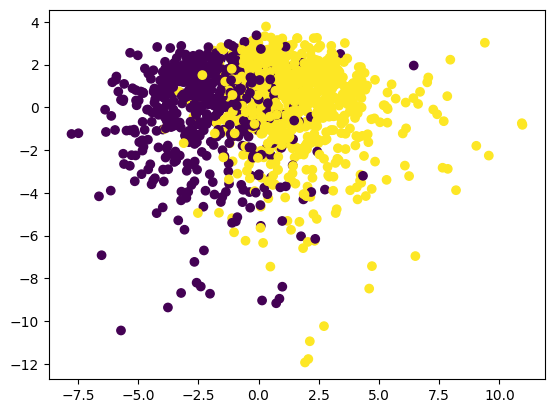

In [304]:
from sklearn.decomposition import PCA

model_PCA = PCA(n_components=3)
X_pca = model_PCA.fit_transform(X)
plt.scatter(X_pca[:,0], X_pca[:,1],c=y,cmap='viridis')
plt.show()

# Import Metrics

In [305]:
from sklearn.metrics import accuracy_score,log_loss

def count_error(y_true,y_pred):
    err = 0
    for i in range(len(y_true)):
        if(y_true[i]!=y_pred[i]): 
            err+=1
    return err

# Training

In [306]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier

In [307]:
list_model = np.array([]) 
str_model = np.array([
    'DecisioneTreeClassifier',
    'RandomForestClassifier',
    'LogisticRegression',
    'SVC',
    'KNeighborsClassifier',
    'MLPClassifier'
    ])

list_model = np.append(list_model, DecisionTreeClassifier(max_depth=1000, criterion='gini',random_state=42, class_weight='balanced'))
list_model = np.append(list_model, RandomForestClassifier(n_estimators=1000, max_depth=1000, criterion='log_loss', random_state=42, ccp_alpha=0.01))
list_model = np.append(list_model, LogisticRegression(max_iter=1000,random_state=42,class_weight='balanced'))
list_model = np.append(list_model, SVC(kernel='rbf', probability=True, degree=4, random_state=42, class_weight='balanced'))
list_model = np.append(list_model, KNeighborsClassifier(n_neighbors=10))
list_model = np.append(list_model, MLPClassifier(hidden_layer_sizes=(100, ), learning_rate_init=0.01, max_iter=1000, tol=0.0001, random_state=42))

In [308]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

accuracy_array = np.array([])

for i in range(len(list_model)):
    print(f"Modello = {str_model[i]}")
    start_time = time.time()
    print(list_model[i])
    list_model[i].fit(X_train,y_train)

    pred_Train = list_model[i].predict(X_train)
    pred_proba_Train = list_model[i].predict_proba(X_train)
    pred_Test = list_model[i].predict(X_test)
    pred_proba_Test = list_model[i].predict_proba(X_test)
    
    acc_test = accuracy_score(y_test, pred_Test)
    accuracy_array = np.append(accuracy_array,acc_test)
    print(f"Accuracy train = {accuracy_score(y_train, pred_Train)},loss train = {log_loss(y_train, pred_proba_Train)}, errors train = {count_error(y_train, pred_Train)} out of {len(y_train)}")
    print(f"Accuracy test = {acc_test},loss test = {log_loss(y_test, pred_proba_Test)}, errors test = {count_error(y_test, pred_Test)} out of {len(y_test)}")
    print(f"Training time = {time.time()-start_time}s")
    print()    

Modello = DecisioneTreeClassifier
DecisionTreeClassifier(class_weight='balanced', max_depth=1000, random_state=42)
Accuracy train = 1.0,loss train = 2.2204460492503136e-16, errors train = 0 out of 966
Accuracy test = 0.782608695652174,loss test = 7.835576823721121, errors test = 70 out of 322
Training time = 0.02321791648864746s

Modello = RandomForestClassifier
RandomForestClassifier(ccp_alpha=0.01, criterion='log_loss', max_depth=1000,
                       n_estimators=1000, random_state=42)
Accuracy train = 0.8913043478260869,loss train = 0.25059831761026824, errors train = 105 out of 966
Accuracy test = 0.8571428571428571,loss test = 0.31966820465387397, errors test = 46 out of 322
Training time = 3.9953322410583496s

Modello = LogisticRegression
LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
Accuracy train = 0.8695652173913043,loss train = 0.321300055035888, errors train = 126 out of 966
Accuracy test = 0.8571428571428571,loss test = 0.33413544876988

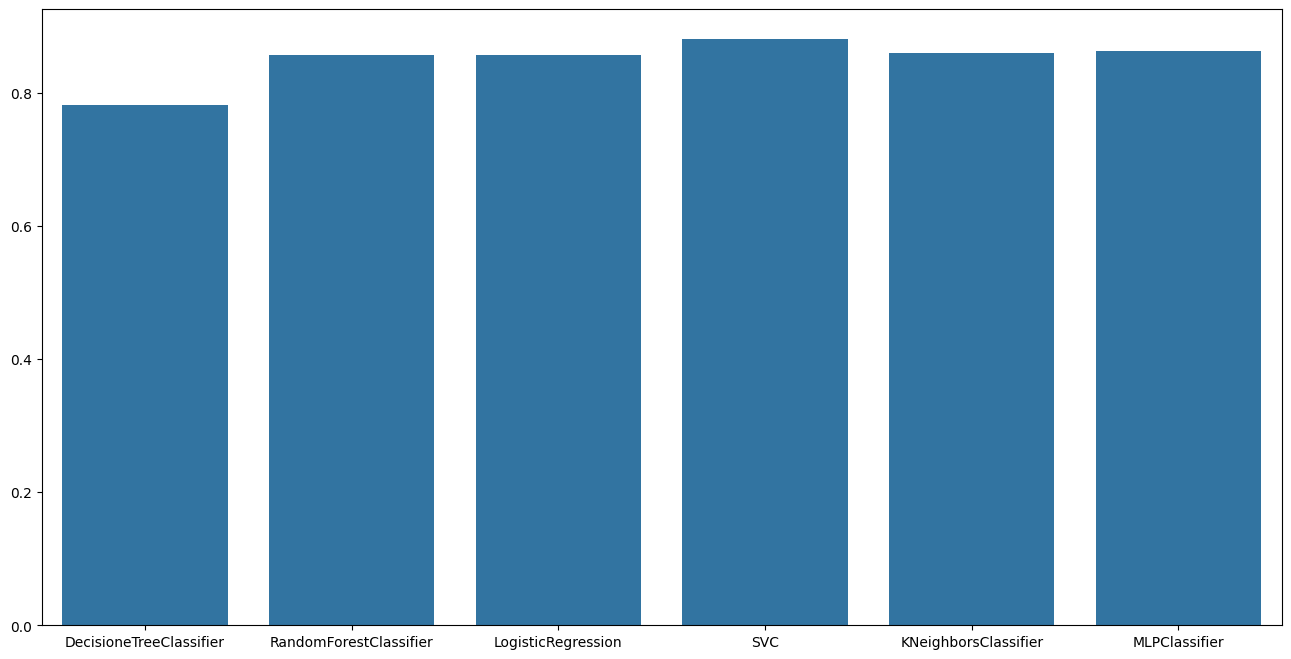

In [309]:
plt.figure(figsize=(16,8))
sns.barplot(x=str_model,y=accuracy_array)
plt.show()

In [310]:
data_test = pd.read_csv("data/test.csv")
X_test = data_test
X_test_scaled = scaler.transform(X_test)
X_test_scaled

array([[ 1.01817831,  1.17197823,  0.01342511, ..., -0.03631212,
         1.33054092, -0.02685176],
       [-0.1097976 ,  1.96525483, -0.23820434, ..., -0.03631212,
         0.14634585, -0.07414218],
       [-0.42184378,  0.6347365 , -0.15738918, ..., -0.03631212,
        -0.3705393 ,  0.01255693],
       ...,
       [ 0.41333179, -0.59671567,  1.05895292, ..., -0.63979614,
        -0.63618306, -0.26527429],
       [ 0.47091404, -0.71420613,  0.30575226, ..., -0.63979614,
         0.25516377,  0.81452365],
       [-2.21690472, -1.05171762, -2.02467297, ...,  1.17065591,
        -0.9642371 ,  0.22733426]])

In [311]:
i=3

pred_Test = list_model[i].predict(X_test_scaled)
pred_proba_Test = list_model[i].predict_proba(X_test_scaled)

In [312]:
ans = pd.read_csv("results/answers_11.csv", header=None)
ans.values.flatten()

array([0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1,
       0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0,
       0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1,
       1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1,
       1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1,
       0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0,
       1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0,
       0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1,
       1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1,

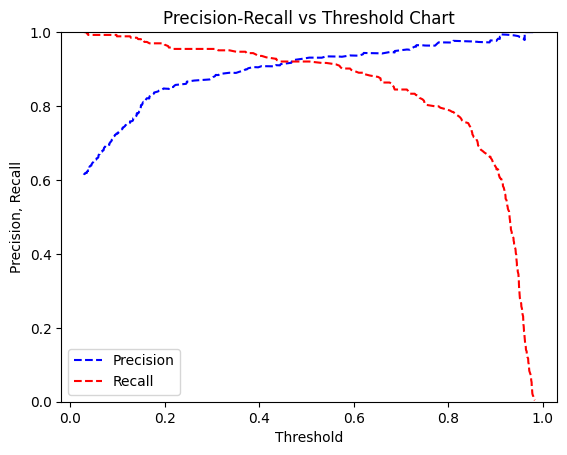

In [313]:
from sklearn.metrics import precision_recall_curve, auc, accuracy_score


precision, recall, thresholds = precision_recall_curve(ans.values.flatten(), pred_proba_Test[:, 1]) 

   #retrieve probability of being 1(in second column of probs_y)
pr_auc = auc(recall, precision)

plt.title("Precision-Recall vs Threshold Chart")
plt.plot(thresholds, precision[: -1], "b--", label="Precision")
plt.plot(thresholds, recall[: -1], "r--", label="Recall")
plt.ylabel("Precision, Recall")
plt.xlabel("Threshold")
plt.legend(loc="lower left")
i =plt.ylim([0,1])

In [322]:
i = 3
def custom_predict(X, threshold):
    probs = list_model[i].predict_proba(X) 
    return (probs[:, 1] > threshold).astype(int)

# 0.596
new_preds = custom_predict(X=X_test_scaled, threshold=0.54) 
accuracy_score(ans.values.flatten(), new_preds)

0.9093023255813953

In [343]:
mistakes = data_test[new_preds != ans.values.flatten()]
mistakes = mistakes.sort_values(by='area', ascending=False)
mistakes

,area,perimeter,major_axis,minor_axis,eccentricity,eqdiasq,solidity,convex_area,extent,aspect_ratio,roundness,compactness,shapefactor_1,shapefactor_2,shapefactor_3,shapefactor_4
360,93818,1233.8879,478.6811,251.6749,0.8506,345.6194,0.9848,95264,0.7732,1.9020,0.7744,0.7220,0.0051,0.0027,0.5213,0.9915
169,93519,1349.2090,503.8502,245.6231,0.8731,345.0682,0.9515,98282,0.7195,2.0513,0.6456,0.6849,0.0054,0.0026,0.4690,0.9621
385,92325,1471.1510,466.4131,259.0960,0.8315,342.8583,0.9490,97287,0.7653,1.8002,0.5361,0.7351,0.0051,0.0028,0.5404,0.9727
355,91090,1241.6550,482.3434,244.1972,0.8624,340.5575,0.9797,92981,0.7762,1.9752,0.7425,0.7060,0.0053,0.0027,0.4985,0.9847
324,89192,1221.6160,470.1267,251.2646,0.8452,336.9908,0.9471,94176,0.6924,1.8710,0.7510,0.7168,0.0053,0.0028,0.5138,0.9614
333,89192,2021.3860,481.0753,249.5452,0.8549,336.9908,0.9223,96702,0.6876,1.9278,0.2743,0.7005,0.0054,0.0028,0.4907,0.9460
14,88455,2006.8060,477.3607,243.7657,0.8598,335.5956,0.9525,92868,0.7091,1.9583,0.2760,0.7030,0.0054,0.0028,0.4942,0.9679
159,88120,1266.1370,462.0862,246.7303,0.8455,334.9595,0.9753,90350,0.7594,1.8728,0.6908,0.7249,0.0052,0.0028,0.5255,0.9841
32,87771,1319.5170,454.6037,252.8515,0.8310,334.2955,0.9446,92915,0.7355,1.7979,0.6335,0.7354,0.0052,0.0029,0.5407,0.9722
70,87582,2388.7800,453.0429,272.2150,0.7994,333.9354,0.8805,99467,0.6843,1.6643,0.1929,0.7371,0.0052,0.0031,0.5433,0.9042


In [346]:
mistakes['minor_axis'] * mistakes['aspect_ratio'] - mistakes['major_axis']

360    0.004560
169   -0.003535
385    0.011519
355   -0.005091
324   -0.010633
333   -0.002063
14     0.005670
159   -0.009694
32    -0.001988
70     0.004524
404    0.007827
362    0.013244
427   -0.006817
51    -0.011186
242    0.009663
26     0.002029
35    -0.005877
37     0.000929
81     0.007590
371    0.008370
198    0.002765
402    0.000740
42    -0.005848
273    0.000284
235   -0.006043
173   -0.010614
244   -0.007840
165    0.008548
45     0.009759
303    0.012229
405    0.006860
249   -0.001322
316   -0.008442
162   -0.011259
352    0.006839
263    0.009934
237    0.005616
406    0.011953
144   -0.007334
dtype: float64

In [337]:
mistakes['convex_area'] * mistakes.solidity	 - mistakes['area']

14     1.7700
26     1.7221
32    -3.4910
35     1.6959
37    -4.4128
42     3.4862
45     2.7285
51    -0.6596
70    -1.3065
81     2.0663
144    0.3034
159   -1.6450
162   -1.3532
165   -1.0304
169   -3.6770
173   -0.6772
198   -1.1911
235    3.7010
237   -0.9144
242    4.0504
244   -2.1504
249   -3.2480
263    1.9971
273   -4.3455
303   -0.2905
316   -2.2147
324    2.0896
333   -3.7454
352    3.3322
355    3.4857
360   -2.0128
362   -2.8122
371   -1.6112
385    0.3630
402    0.9360
404    0.2896
405    1.5300
406   -3.4362
427   -3.7114
dtype: float64